# META - Opciones
##### Maria Fernanda Gómez Flores
##### 23 de Septiembre 2026

## Precios de META

In [11]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [12]:
ticker="META"

df = yf.download(ticker, period='6mo')
df
prices = df['Close']
#si quiero que no cuente el dato de hoy 
prices = prices[:-1]
prices.tail()

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_79786/2619754829.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='6mo')
[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2026-09-16,672.779053
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000
2026-09-22,736.599976


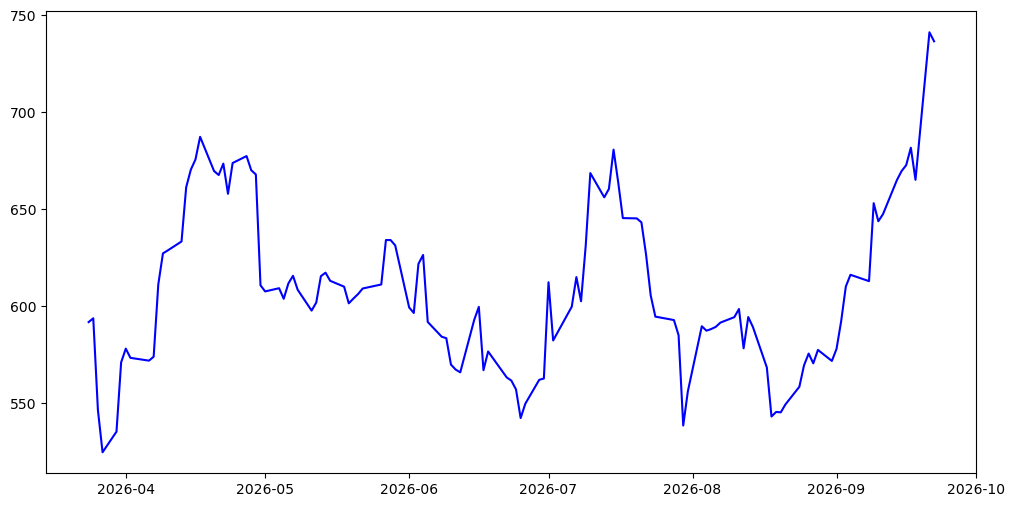

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices.values, label='META Closing Prices', color='blue')
plt.show()

# Tipos de opciones

Ahora voy a calcular el payoff de una opcion europea asiatica y lookback usando los precios reales de META y tomando K = S0.

## Opción Europea

Primero voy a calcular la opcion europea. Esta opcion solo toma en cuenta el precio final ST para calcular el payoff del call y del put.

In [14]:
S0 = df["Close"].iloc[0].item()
ST = df["Close"].iloc[-1].item()
K = S0

S0, ST, K

(591.9038696289062, 744.0999755859375, 591.9038696289062)

In [15]:
payoff_call_EU = max(ST - K, 0)

payoff_put_EU = max(K - ST, 0)

payoff_call_EU, payoff_put_EU

(152.19610595703125, 0)

La call tiene ganancia porque ST termino arriba de K mientras que la put queda en 0 porque no conviene ejercerla.

## Opción Asiática

Ahora voy a calcular la opcion asiatica usando el promedio de los precios de META durante los 6 meses en lugar de solamente usar el precio final.

In [16]:
promedio = df["Close"].mean().item()

promedio

609.6598645307886

In [17]:
payoff_call_AS = max(promedio - K, 0)

payoff_put_AS = max(K - promedio, 0)

payoff_call_AS, payoff_put_AS

(17.75599490188233, 0)

En este caso el precio promedio queda arriba de K entonces la call tiene ganancia y la put queda en 0.

## Opción Lookback

Para la opcion lookback voy a obtener el precio maximo y minimo que tuvo META durante el periodo. Para la call voy a usar el precio final menos el minimo y para la put el maximo menos el precio final.

In [18]:
maximo = df["Close"].max().item()
minimo = df["Close"].min().item()

payoff_call_LB = ST - minimo
payoff_put_LB = maximo - ST

payoff_call_LB, payoff_put_LB

(219.28094482421875, 0.0)

La opcion lookback toma en cuenta los precios extremos que tuvo META durante todo el periodo y no solamente el precio con el que termino.

# Simulación de precios

Ahora voy a usar los precios de META desde el 23 de septiembre de 2025 hasta el 23 de marzo de 2026 para estimar la media y la volatilidad de sus rendimientos.

Con estos datos voy a simular los precios de META para los siguientes 6 meses hasta el 23 de septiembre de 2026 y despues compararlos contra los precios que realmente tuvo la accion.

In [19]:
df = yf.download(ticker,start="2025-09-23",end="2026-09-24")

Prices = df["Close"]

rets = np.log(Prices / Prices.shift(1))
rets = rets.dropna()

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_79786/2654514626.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker,start="2025-09-23",end="2026-09-24")
[*********************100%***********************]  1 of 1 completed


## Train y Test

Primero voy a calcular los rendimientos logaritmicos y separar los datos en Train y Test.

Train contiene los primeros 6 meses y lo voy a usar para calcular la media y volatilidad. Test contiene los siguientes 6 meses y lo voy a usar para comparar lo simulado contra lo que realmente paso.

In [20]:
Train = rets[(rets.index >= "2025-09-23") &(rets.index <= "2026-03-23")]
Test = rets[(rets.index > "2026-03-23") &(rets.index <= "2026-09-23")]

## Media volatilidad y simulación

Con los rendimientos del Train voy a calcular la media y volatilidad diaria que voy a usar para hacer las simulaciones.

Tambien voy a tomar como S0 el ultimo precio del Train que corresponde al 23 de marzo de 2026.

Voy a realizar 10000 simulaciones para los siguientes 126 dias bursatiles. Todas las simulaciones empiezan desde el mismo S0 pero cada una puede seguir un camino diferente por los valores aleatorios de Z.

In [21]:
Mu = Train.mean()
Sigma = Train.std()
S0 = Prices.loc[:"2026-03-23"].iloc[-1]

M = 10000
n = 126

mu = Mu["META"]
sigma = Sigma["META"]
s0 = S0["META"]

# Simulación
np.random.seed(32)

Z = np.random.normal(0, 1, size=(M, n))

precios = np.zeros((M, n + 1))
precios[:, 0] = s0

for t in range(1, n + 1):
    precios[:, t] = precios[:, t-1] * np.exp(
        mu + sigma * Z[:, t-1]
    )

## Comparación con los precios reales

Para poder ver mejor los resultados voy a graficar 100 de las 10000 trayectorias simuladas y encima voy a poner los precios reales de META para comparar lo que genero la simulacion contra lo que realmente paso.

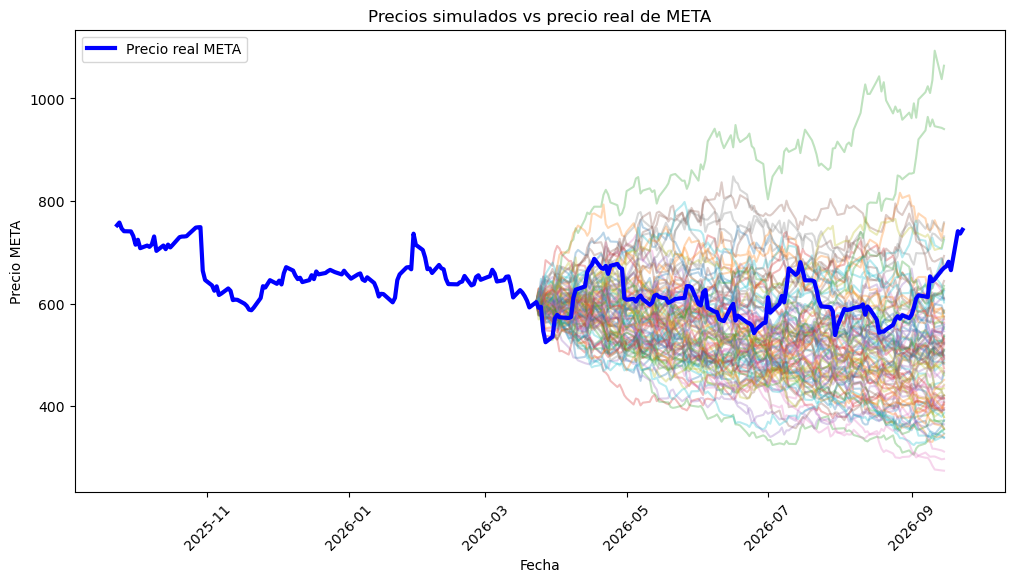

In [24]:
fechas = pd.bdate_range(
    start="2026-03-23",
    periods=n + 1
)

plt.figure(figsize=(12,6))

# 100 precios simulados desde marzo
for i in range(100):
    plt.plot(fechas, precios[i], alpha=0.3)

# Precio real de META desde septiembre 2025
plt.plot(
    Prices.index,
    Prices.values,
    label="Precio real META",
    color="blue",
    linewidth=3
)

plt.xlabel("Fecha")
plt.ylabel("Precio META")
plt.title("Precios simulados vs precio real de META")

plt.legend()
plt.xticks(rotation=45)

plt.show()

## Conclusión

Usando los primeros 6 meses pude obtener la media y volatilidad de los rendimientos de META y con estos datos simule 10000 posibles trayectorias para los siguientes 126 dias.

En la grafica muestro solamente 100 simulaciones para poder verlas mejor y las comparo contra el precio real de META. Se puede ver que las simulaciones generan diferentes escenarios posibles a partir del comportamiento que tuvo la accion en el Train pero no buscan predecir exactamente el camino que va a seguir el precio.